## Step 1 — Install Dependencies

In [ ]:
!pip install pytorch-crf seqeval datasets transformers torch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Imports and Device Setup

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.optim import AdamW
from transformers import BertTokenizerFast, BertModel, get_linear_schedule_with_warmup
from torchcrf import CRF  # pytorch-crf package
from seqeval.metrics import classification_report, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Step 3 — Load Dataset

**Critical:** We always use `STIX_Tag`, never `Tag`. They differ.

In [ ]:
df = pd.read_csv('cyberner_combined_stix.csv', encoding='utf-8', keep_default_na=False)

In [ ]:
# --- Sanity checks ---
print(f'Total rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
assert 'STIX_Tag' in df.columns, 'STIX_Tag column not found!'
assert 'Word' in df.columns, 'Word column not found!'
assert 'Sentence_ID' in df.columns, 'Sentence_ID column not found!'

# Drop any rows with empty words or labels
df = df[df['Word'].notna() & df['STIX_Tag'].notna()]
df['Word'] = df['Word'].astype(str)
df['STIX_Tag'] = df['STIX_Tag'].astype(str)

# --- Label distribution ---
tag_counts = Counter(df['STIX_Tag'].tolist())
total_tokens = sum(tag_counts.values())
print(f'\nLabel distribution (using STIX_Tag):')
for tag, count in tag_counts.most_common():
    print(f'  {tag:<35} {count:>8}  ({100*count/total_tokens:.1f}%)')

o_pct = 100 * tag_counts.get('O', 0) / total_tokens
if o_pct > 90:
    print(f'\n⚠️  WARNING: {o_pct:.1f}% of tokens are O — class imbalance is severe.')
    print('   Weighted sampling will be applied automatically.')

Total rows: 609922
Columns: ['Word', 'Tag', 'Sentence_ID', 'STIX_Tag', 'Source']

Label distribution (using STIX_Tag):
  O                                     506674  (83.1%)
  I-Attack-Pattern                       11915  (2.0%)
  B-Identity                             10577  (1.7%)
  B-Threat-Actor                          9408  (1.5%)
  B-Malware                               7700  (1.3%)
  B-Tool                                  7045  (1.2%)
  I-Identity                              6874  (1.1%)
  B-Location                              5740  (0.9%)
  B-Attack-Pattern                        5293  (0.9%)
  I-Malware-Analysis                      3459  (0.6%)
  I-Course-of-Action                      3409  (0.6%)
  I-Tool                                  3215  (0.5%)
  I-Indicator                             3053  (0.5%)
  I-Threat-Actor                          2743  (0.4%)
  B-Vulnerability                         2582  (0.4%)
  I-Malware                               2576  (0.4%)


step 3.1 group related entities

In [ ]:
collapse_map = {

    # Malware
    "Malware": "Malware",
    "Malware-Analysis": "Malware",

    # Tools / software
    "Software": "Tool",
    "Tool": "Tool",

    # Threat actors
    "Threat-Actor": "Threat-Actor",
    "Intrusion-Set": "Threat-Actor",
    "Campaign": "Threat-Actor",

    # Organization / identity
    "Identity": "Organization",

    # Attack patterns
    "Attack-Pattern": "Attack-Pattern",

    # Vulnerabilities
    "Vulnerability": "Vulnerability",

    # Files
    "File": "File",

    # Indicators
    "Indicator": "Indicator",
    "Domain-Name": "Indicator",
    "IPv4-Addr": "Indicator",
    "URL": "Indicator",
    "Email-Addr": "Indicator",
    "Infrastructure": "Indicator",

    # Network
    "Network-Traffic": "Network-Traffic",

    # Location
    "Location": "Location",

    # Remove noisy labels
    "Observed-Data": "O",
    "Course-of-Action": "O"
}

In [ ]:
def collapse_stix(tag):

    if tag == "O":
        return "O"

    prefix, entity = tag.split("-", 1)

    new_entity = collapse_map.get(entity, entity)

    if new_entity == "O":
        return "O"

    return f"{prefix}-{new_entity}"

In [ ]:
df["STIX_Tag"] = df["STIX_Tag"].apply(collapse_stix)

In [ ]:
print(df["STIX_Tag"].unique())

['B-Malware' 'I-Malware' 'O' 'B-Tool' 'I-Tool' 'B-Organization'
 'B-Indicator' 'I-Organization' 'I-Indicator' 'B-Vulnerability'
 'I-Vulnerability' 'B-Threat-Actor' 'B-Location' 'I-Location'
 'I-Threat-Actor' 'B-Attack-Pattern' 'I-Attack-Pattern' 'B-File'
 'B-Network-Traffic' 'I-File' 'I-Network-Traffic']


In [ ]:
# --- Load ---

# --- Sanity checks ---
print(f'Total rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
assert 'STIX_Tag' in df.columns, 'STIX_Tag column not found!'
assert 'Word' in df.columns, 'Word column not found!'
assert 'Sentence_ID' in df.columns, 'Sentence_ID column not found!'

# Drop any rows with empty words or labels
df = df[df['Word'].notna() & df['STIX_Tag'].notna()]
df['Word'] = df['Word'].astype(str)
df['STIX_Tag'] = df['STIX_Tag'].astype(str)

# --- Label distribution ---
tag_counts = Counter(df['STIX_Tag'].tolist())
total_tokens = sum(tag_counts.values())
print(f'\nLabel distribution (using STIX_Tag):')
for tag, count in tag_counts.most_common():
    print(f'  {tag:<35} {count:>8}  ({100*count/total_tokens:.1f}%)')

o_pct = 100 * tag_counts.get('O', 0) / total_tokens
if o_pct > 90:
    print(f'\n⚠️  WARNING: {o_pct:.1f}% of tokens are O — class imbalance is severe.')
    print('   Weighted sampling will be applied automatically.')

Total rows: 609922
Columns: ['Word', 'Tag', 'Sentence_ID', 'STIX_Tag', 'Source']

Label distribution (using STIX_Tag):
  O                                     513186  (84.1%)
  I-Attack-Pattern                       11915  (2.0%)
  B-Organization                         10577  (1.7%)
  B-Threat-Actor                          9772  (1.6%)
  B-Malware                               8861  (1.5%)
  B-Tool                                  8632  (1.4%)
  I-Organization                          6874  (1.1%)
  I-Malware                               6035  (1.0%)
  B-Location                              5740  (0.9%)
  B-Attack-Pattern                        5293  (0.9%)
  I-Tool                                  3944  (0.6%)
  I-Indicator                             3734  (0.6%)
  I-Threat-Actor                          3426  (0.6%)
  B-Indicator                             2745  (0.5%)
  B-Vulnerability                         2582  (0.4%)
  B-File                                  2169  (0.4%)


## Step 4 — Build Label Map and Reconstruct Sentences

In [ ]:
# Build label map from STIX_Tag only
all_stix_labels = sorted(set(df['STIX_Tag'].tolist()))
label2id = {label: i for i, label in enumerate(all_stix_labels)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(label2id)

print(f'Number of unique labels: {num_labels}')
print(f'Labels: {all_stix_labels}')

# Reconstruct sentence lists from dataframe
sentences = []
labels_list = []

for sent_id, group in df.groupby('Sentence_ID'):
    words = group['Word'].tolist()
    tags  = group['STIX_Tag'].tolist()  # STIX_Tag — not Tag
    sentences.append(words)
    labels_list.append(tags)

print(f'\nTotal sentences: {len(sentences)}')
print(f'Example sentence 0: {sentences[0]}')
print(f'Example labels  0: {labels_list[0]}')

Number of unique labels: 21
Labels: ['B-Attack-Pattern', 'B-File', 'B-Indicator', 'B-Location', 'B-Malware', 'B-Network-Traffic', 'B-Organization', 'B-Threat-Actor', 'B-Tool', 'B-Vulnerability', 'I-Attack-Pattern', 'I-File', 'I-Indicator', 'I-Location', 'I-Malware', 'I-Network-Traffic', 'I-Organization', 'I-Threat-Actor', 'I-Tool', 'I-Vulnerability', 'O']

Total sentences: 10042
Example sentence 0: ['Super', 'Mario', 'Run', 'Malware', '#', '2', '–', 'DroidJack', 'RAT', 'Gamers', 'love', 'Mario', 'and', 'Pokemon', ',', 'but', 'so', 'do', 'malware', 'authors', '.', 'The', 'admin@338', 'has', 'largely', 'targeted', 'organizations', 'involved', 'in', 'financial', ',', 'economic', 'and', 'trade', 'policy', ',', 'typically', 'using', 'publicly', 'available', 'RATs', 'such', 'as', 'Poison', 'Ivy', ',', 'as', 'well', 'some', 'non-public', 'backdoors', '.', 'From', 'April', '19-24', ',', '2017', ',', 'a', 'politically-motivated', ',', 'targeted', 'campaign', 'was', 'carried', 'out', 'against', 

## Step 5 — Train / Val / Test Split

In [ ]:
# 80% train, 10% val, 10% test
train_sents, temp_sents, train_labels, temp_labels = train_test_split(
    sentences, labels_list, test_size=0.2, random_state=42
)
val_sents, test_sents, val_labels, test_labels = train_test_split(
    temp_sents, temp_labels, test_size=0.5, random_state=42
)

# Ensure all strings
train_sents  = [[str(t) for t in s] for s in train_sents]
train_labels = [[str(l) for l in s] for s in train_labels]
val_sents    = [[str(t) for t in s] for s in val_sents]
val_labels   = [[str(l) for l in s] for s in val_labels]
test_sents   = [[str(t) for t in s] for s in test_sents]
test_labels  = [[str(l) for l in s] for s in test_labels]

print(f'Train: {len(train_sents)} | Val: {len(val_sents)} | Test: {len(test_sents)}')

Train: 8033 | Val: 1004 | Test: 1005


## Step 6 — Tokenizer and Alignment

Key rule: **only the first subword of each word gets the real label. All other positions get -100 (ignored by the CRF mask).**

In [ ]:
zip_file = '/content/cti-bert-dapt-final.zip' # @param {type: "string"}
destination_folder = '/content/cti-bert-dapt-final' # @param {type: "string"}

# Create the destination folder if it doesn't exist
!mkdir -p "{destination_folder}"

# Unzip the file into the specified destination folder
!unzip "{zip_file}" -d "{destination_folder}"

Archive:  /content/cti-bert-dapt-final.zip
  inflating: /content/cti-bert-dapt-final/config.json  
  inflating: /content/cti-bert-dapt-final/tokenizer.json  
  inflating: /content/cti-bert-dapt-final/tokenizer_config.json  
  inflating: /content/cti-bert-dapt-final/model.safetensors  
  inflating: /content/cti-bert-dapt-final/training_args.bin  


In [ ]:
# Load tokenizer from your DAPT model
tokenizer = BertTokenizerFast.from_pretrained('cti-bert-dapt-final')
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')
print(f'Model max length: {tokenizer.model_max_length}')

MAX_LEN = 128  # safe for T4; increase to 256 if needed


def tokenize_and_align(batch_sentences, batch_labels):
    """
    Tokenize a batch and align labels to first-subword positions only.
    All other positions (special tokens, continuation subwords) get -100.
    """
    tokenized = tokenizer(
        batch_sentences,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        is_split_into_words=True,
        return_tensors='pt'
    )

    aligned_labels = []
    for i, label_seq in enumerate(batch_labels):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                # [CLS], [SEP], [PAD]
                label_ids.append(-100)
            elif word_idx != prev_word:
                # First subword of a new word — assign real label
                label_ids.append(label2id[label_seq[word_idx]])
            else:
                # Continuation subword — IGNORE, do not supervise
                label_ids.append(-100)
            prev_word = word_idx
        aligned_labels.append(label_ids)

    tokenized['labels'] = torch.tensor(aligned_labels, dtype=torch.long)
    return tokenized

Tokenizer vocab size: 30522
Model max length: 512


## Step 7 — PyTorch Dataset

In [ ]:
class NERDataset(Dataset):
    def __init__(self, sentences, labels, batch_size=64):
        """
        Tokenizes in batches to avoid memory issues on large datasets.
        Stores each sample individually for DataLoader compatibility.
        """
        self.samples = []
        for i in range(0, len(sentences), batch_size):
            batch_s = sentences[i:i+batch_size]
            batch_l = labels[i:i+batch_size]
            tokenized = tokenize_and_align(batch_s, batch_l)
            for j in range(len(batch_s)):
                self.samples.append({
                    'input_ids':      tokenized['input_ids'][j],
                    'attention_mask': tokenized['attention_mask'][j],
                    'labels':         tokenized['labels'][j],
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


print('Building datasets...')
train_dataset = NERDataset(train_sents, train_labels)
val_dataset   = NERDataset(val_sents,   val_labels)
test_dataset  = NERDataset(test_sents,  test_labels)
print(f'Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}')

Building datasets...
Train size: 8033 | Val size: 1004 | Test size: 1005


## Step 8 — Weighted Sampler

In [ ]:
def compute_sample_weights(dataset):
    """Give higher weight to sentences that contain entity tokens."""
    weights = []
    for sample in dataset.samples:
        lbl = sample['labels']
        # Count real labels (not -100) that are not O (id of O)
        o_id = label2id['O']
        entity_count = ((lbl != -100) & (lbl != o_id)).sum().item()
        # Weight = entity tokens + 1 (at least 1 to avoid zero-weight)
        weights.append(float(entity_count + 1))
    return weights

train_weights = compute_sample_weights(train_dataset)
sampler = WeightedRandomSampler(
    weights=train_weights,
    num_samples=len(train_weights),
    replacement=True
)

# DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches per epoch: {len(train_loader)}')

Batches per epoch: 503


In [ ]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches per epoch: {len(train_loader)}')

Batches per epoch: 503


## Step 9 — Model: BertDCCRF


In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel
from torchcrf import CRF


class BertATCRF(nn.Module):

    def __init__(self, num_labels,
                 model_path="cti-bert-dapt-final",
                 dropout=0.1):

        super().__init__()

        self.num_labels = num_labels

        # BERT encoder
        self.bert = BertModel.from_pretrained(model_path)

        self.dropout = nn.Dropout(dropout)

        hidden = self.bert.config.hidden_size

        # emission scores
        self.classifier = nn.Linear(hidden, num_labels)

        # adaptive transition generator
        self.transition_generator = nn.Linear(
            hidden, num_labels * num_labels
        )

        # CRF layer
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        sequence_output = self.dropout(outputs.last_hidden_state)
        print("BERT embedding shape:", sequence_output.shape)
        print("Sample embedding token 0:", sequence_output[0,0,:10])

        # emissions
        emissions = self.classifier(sequence_output)
        print("Emission shape:", emissions.shape)
        print("Emission example:", emissions[0,0])
        # generate dynamic transitions
        B, L, H = sequence_output.shape

        transition_logits = self.transition_generator(sequence_output)

        transitions = transition_logits.view(
            B, L, self.num_labels, self.num_labels
        )
        print("Transition tensor shape:", transitions.shape)
        # average transitions across sequence
        dynamic_transition = transitions.mean(dim=1)

        # replace CRF transitions
        self.crf.transitions.data = dynamic_transition.mean(dim=0)

        if labels is not None:

            valid_mask = (labels != -100) & attention_mask.bool()

            safe_labels = labels.clone()
            safe_labels[safe_labels == -100] = 0

            valid_count = valid_mask.sum().float().clamp(min=1.0)

            loss = -self.crf(
                emissions,
                safe_labels,
                mask=valid_mask,
                reduction="sum"
            )

            return loss / valid_count

        else:

            return self.crf.decode(
                emissions,
                mask=attention_mask.bool()
            )

In [ ]:
model = BertATCRF(
    num_labels=num_labels)

model = model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cti-bert-dapt-final
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Step 10 — Optimizer and Scheduler

Different learning rates for BERT encoder vs CRF/classifier head — standard best practice.

In [ ]:
NUM_EPOCHS = 15
WARMUP_RATIO = 0.1

# Separate parameter groups: lower LR for BERT, higher for head
bert_params = list(model.bert.named_parameters())
head_params = list(model.classifier.named_parameters()) + list(model.crf.named_parameters())

no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    # BERT — with weight decay
    {'params': [p for n, p in bert_params if not any(nd in n for nd in no_decay)],
     'lr': 2e-5, 'weight_decay': 0.01},
    # BERT — no weight decay (bias/LN)
    {'params': [p for n, p in bert_params if     any(nd in n for nd in no_decay)],
     'lr': 2e-5, 'weight_decay': 0.0},
    # CRF + classifier head — higher LR
    {'params': [p for n, p in head_params if not any(nd in n for nd in no_decay)],
     'lr': 5e-4, 'weight_decay': 0.01},
    {'params': [p for n, p in head_params if     any(nd in n for nd in no_decay)],
     'lr': 5e-4, 'weight_decay': 0.0},
]

optimizer = AdamW(optimizer_grouped)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')
print(f'Warmup steps: {int(WARMUP_RATIO * total_steps)}')

Total training steps: 7545
Warmup steps: 754


## Step 11 — Evaluation Function

In [ ]:
def evaluate(model, loader, split_name='Val'):
    """
    Runs model on loader and returns seqeval F1 + full per-class report.
    Filters out -100 positions before scoring.
    """
    model.eval()
    all_preds  = []
    all_truths = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            # decoded: list of lists of ints (one list per sentence)
            decoded = model(input_ids, attention_mask)

            for i, pred_ids in enumerate(decoded):
                true_ids = labels[i].cpu().tolist()
                pred_labels_seq  = []
                true_labels_seq  = []
                for pred_id, true_id in zip(pred_ids, true_ids):
                    if true_id == -100:
                        continue  # skip padding / subword / special tokens
                    pred_labels_seq.append(id2label[pred_id])
                    true_labels_seq.append(id2label[true_id])
                all_preds.append(pred_labels_seq)
                all_truths.append(true_labels_seq)

    micro_f1 = f1_score(all_truths, all_preds)
    report   = classification_report(all_truths, all_preds, output_dict=False, zero_division=0)

    print(f'\n--- {split_name} Results ---')
    print(f'Micro F1: {micro_f1:.4f}')
    print(report)
    return micro_f1, all_truths, all_preds

## Step 12 — Training Loop with Early Stopping

In [ ]:
PATIENCE        = 5     # stop if val F1 doesn't improve for 3 epochs
SAVE_PATH       = 'ctibert_ner_atcrf_best.pt'
GRAD_CLIP       = 1.0

best_val_f1     = 0.0
patience_count  = 0
history         = {'train_loss': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    # ---- TRAIN ----
    model.train()
    total_loss    = 0.0
    total_batches = 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        # --- FIX 1: build mask BEFORE replacing -100 ---
        # valid_mask = True only at first-subword positions
        # The original `valid_mask = (labels != -100) & attention_mask.bool()`
        # caused ValueError because labels[:, 0] is -100 for [CLS] tokens.
        # The CRF mask must have its first timestep all True.
        # We will create a crf_mask for the CRF layer's internal operations
        # and ensure its first timestep is True, while preserving the logic for loss normalization.

        # Prepare labels for CRF: replace -100 with a valid label ID (e.g., 'O')
        safe_labels = labels.clone()
        o_label_id = label2id['O'] # Get the ID for the 'O' (Outside) tag
        safe_labels[safe_labels == -100] = o_label_id

        # Prepare mask for CRF operation: use attention_mask, ensuring first timestep is True
        crf_operational_mask = attention_mask.bool()

        # Calculate CRF loss (using reduction='none' to handle per-sequence normalization later)
        per_sequence_nll = -model.crf(
            emissions=model.classifier(model.dropout(model.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)),
            tags=safe_labels,
            mask=crf_operational_mask,
            reduction='none'
        )

        # --- FIX 2 & 3: Normalize loss by valid tokens ---
        # Calculate the number of truly valid (non -100) tokens for each sequence
        # This mask is for the *actual* loss contribution, excluding [CLS], [SEP], and subword continuations.
        valid_token_mask = ((labels != -100) & attention_mask.bool())
        valid_token_counts = valid_token_mask.sum(dim=1).float().clamp(min=1.0) # Sum valid tokens per sequence

        # Sum the per-sequence negative log-likelihoods, normalized by valid token counts
        loss = (per_sequence_nll / valid_token_counts).sum() # Sum across the batch to get a single scalar loss

        loss.backward()

        # Gradient norm check (should stay < 5 after warmup)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        scheduler.step()

        total_loss    += loss.item()
        total_batches += 1

    avg_loss = total_loss / total_batches
    history['train_loss'].append(avg_loss)

    # ---- VALIDATE ----
    val_f1,all_truths,all_preds = evaluate(model, val_loader, split_name=f'Val Epoch {epoch+1}')
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}')

    # ---- CHECKPOINT ----
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_count = 0
        torch.save({
            'epoch':      epoch + 1,
            'model_state': model.state_dict(),
            'val_f1':     val_f1,
            'label2id':   label2id,
            'id2label':   id2label,
            'num_labels': num_labels,
        }, SAVE_PATH)
        print(f'  ✓ New best saved to {SAVE_PATH} (F1={val_f1:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement. Patience: {patience_count}/{PATIENCE}')
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}.')
            break

print(f'Best validation F1: {best_val_f1:.4f}')

Streaming output truncated to the last 5000 lines.
        -3.0611, -4.9640, -4.0805, -5.1622, 11.4832], device='cuda:0')
Transition tensor shape: torch.Size([16, 128, 21, 21])
BERT embedding shape: torch.Size([16, 128, 768])
Sample embedding token 0: tensor([ 0.3298,  0.3918,  0.7429, -0.1170, -0.4289,  0.0056, -0.2472,  0.8791,
         0.8221, -0.2074], device='cuda:0')
Emission shape: torch.Size([16, 128, 21])
Emission example: tensor([-2.6839, -3.5800, -4.8244, -3.9545, -3.7927, -6.5587, -3.1523, -2.6781,
        -3.1199, -4.1039, -2.6077, -4.4419, -3.6514, -6.3845, -3.0673, -8.2123,
        -3.1566, -5.5675, -3.1796, -5.5225, 11.3211], device='cuda:0')
Transition tensor shape: torch.Size([16, 128, 21, 21])
BERT embedding shape: torch.Size([16, 128, 768])
Sample embedding token 0: tensor([-0.4350,  0.2868,  0.0593,  0.6251,  0.0117,  0.0147,  0.5824,  1.1714,
         0.8134,  0.2928], device='cuda:0')
Emission shape: torch.Size([16, 128, 21])
Emission example: tensor([-2.4037, -3

## Step 13 — Final Evaluation on Test Set

In [ ]:
# Load best checkpoint
checkpoint = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (Val F1={checkpoint['val_f1']:.4f})")

# Test set evaluation
test_f1,_,_ = evaluate(model, test_loader, split_name='TEST SET')
print(f'\nFinal Test F1: {test_f1:.4f}')

Loaded best model from epoch 29 (Val F1=0.7934)

--- TEST SET Results ---
Micro F1: 0.8099
                 precision    recall  f1-score   support

 Attack-Pattern       0.70      0.78      0.74       500
           File       0.78      0.86      0.82       145
      Indicator       0.72      0.82      0.77       275
       Location       0.83      0.90      0.86       515
        Malware       0.77      0.84      0.81       727
Network-Traffic       0.48      0.83      0.61        29
   Organization       0.83      0.86      0.85       961
   Threat-Actor       0.81      0.89      0.85       872
           Tool       0.68      0.78      0.73       774
  Vulnerability       0.91      0.94      0.93       270

      micro avg       0.77      0.85      0.81      5068
      macro avg       0.75      0.85      0.79      5068
   weighted avg       0.78      0.85      0.81      5068



TypeError: unsupported format string passed to tuple.__format__

## Step 14 — Loss Curve Plot

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], 'b-o', label='Train Loss')
ax1.set_title('Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(history['val_f1'], 'g-o', label='Val F1')
ax2.set_title('Validation F1 per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Micro F1')
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Plot saved to training_curves.png')

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def strip_bio(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[1]

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(all_truths, all_preds):

    # Flatten sequences
    y_true = []
    y_pred = []

    for t_seq, p_seq in zip(all_truths, all_preds):
        for t, p in zip(t_seq, p_seq):

            # remove BIO
            if t != "O":
                t = t.split("-")[1]
            if p != "O":
                p = p.split("-")[1]

            # ignore O labels
            if t == "O":
                continue

            y_true.append(t)
            y_pred.append(p)

    labels = sorted(list(set(y_true)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("NER Confusion Matrix")
    plt.tight_layout()

    plt.savefig("confusion_matrix.png", dpi=300)
    plt.show()

    print("Confusion matrix saved as confusion_matrix.png")


--- TEST SET Results ---
Micro F1: 0.7752
                 precision    recall  f1-score   support

 Attack-Pattern       0.65      0.71      0.68       500
           File       0.76      0.78      0.77       145
      Indicator       0.77      0.81      0.79       275
       Location       0.81      0.90      0.85       515
        Malware       0.71      0.80      0.75       727
Network-Traffic       0.52      0.83      0.64        29
   Organization       0.81      0.83      0.82       961
   Threat-Actor       0.77      0.85      0.81       872
           Tool       0.65      0.71      0.68       774
  Vulnerability       0.89      0.92      0.91       270

      micro avg       0.75      0.81      0.78      5068
      macro avg       0.73      0.81      0.77      5068
   weighted avg       0.75      0.81      0.78      5068


Final Test F1: 0.7752


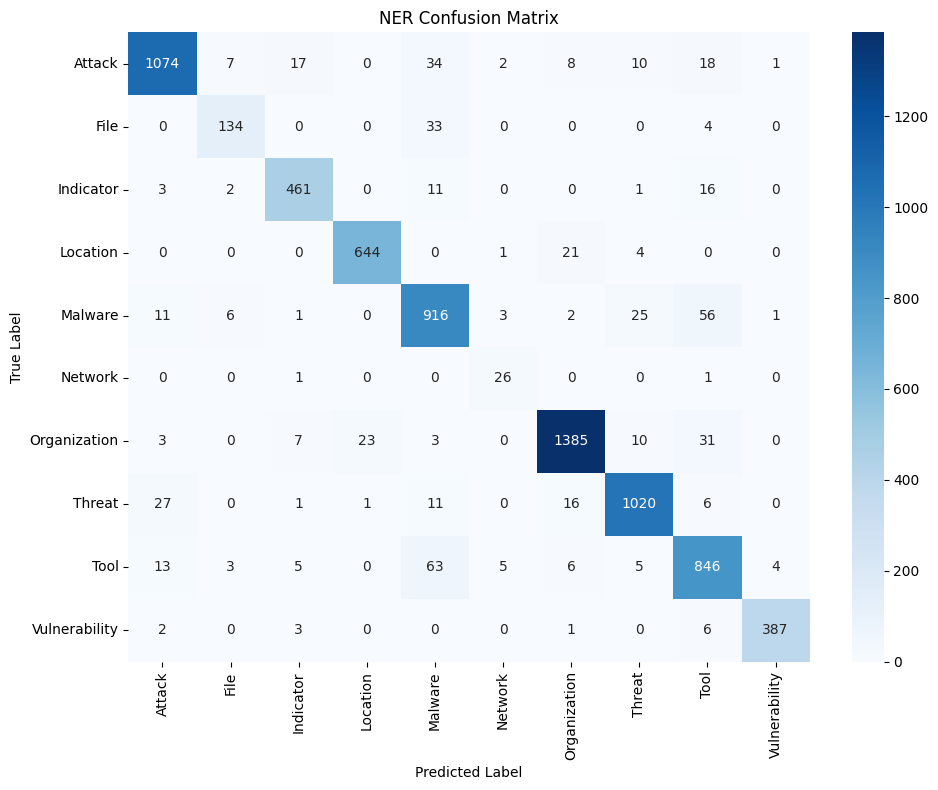

Confusion matrix saved as confusion_matrix.png


In [ ]:
test_f1, all_truths, all_preds = evaluate(model, test_loader, split_name='TEST SET')

print(f'\nFinal Test F1: {test_f1:.4f}')

plot_confusion_matrix(all_truths, all_preds)

## Step 15 — Save Full Model for Deployment

In [ ]:
import json

# Save model weights
torch.save(model.state_dict(), 'ctibert_ner_final_dcbert_weights_v2.pt')

# Save tokenizer
tokenizer.save_pretrained('ctibert_ner_dc_tokenizer_v2')

# Save label maps
with open('ctibert_ner_dc_labels.json', 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2)

print('Saved:')
print('  ctibert_ner_final_weights.pt  — model weights')
print('  ctibert_ner_tokenizer/        — tokenizer')
print('  ctibert_ner_labels.json       — label maps')

In [ ]:
!zip -r /content/ctibert_ner_dc_tokenizer_v2.zip /content/ctibert_ner_dc_tokenizer_v2

In [ ]:
from google.colab import files
files.download('ctibert_ner_final_dcbert_weights_v2.pt')

In [ ]:
from google.colab import files
files.download('/content/ctibert_ner_dc_tokenizer_v2.zip')

In [ ]:
from google.colab import files
files.download('ctibert_ner_dc_labels.json')

## Step 16 — Inference on New Text

Use this function to predict entities from any raw string.

In [ ]:
def predict(text: str, model=model, tokenizer=tokenizer) -> list:
    """
    Run NER on a raw text string.

    Returns:
        List of dicts: [{'text': ..., 'label': ..., 'start': ..., 'end': ...}]

    Example:
        predict("APT29 used Cobalt Strike after exploiting CVE-2021-44228.")
    """
    model.eval()
    words = text.strip().split()
    if not words:
        return []

    encoding = tokenizer(
        [words],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        is_split_into_words=True,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    word_ids       = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        decoded = model(input_ids, attention_mask)  # list of lists

    pred_ids = decoded[0]  # predictions for the single sequence

    # Map predictions back to words (first subword only)
    word_labels = {}
    for token_idx, word_idx in enumerate(word_ids):
        if word_idx is None:
            continue
        if word_idx not in word_labels:  # first subword
            if token_idx < len(pred_ids):
                word_labels[word_idx] = id2label[pred_ids[token_idx]]

    # Build entity spans from BIO tags
    entities = []
    current  = None
    for idx, word in enumerate(words):
        tag = word_labels.get(idx, 'O')

        if tag.startswith('B-'):
            if current:
                entities.append(current)
            current = {'text': word, 'label': tag[2:], 'start': idx, 'end': idx}

        elif tag.startswith('I-') and current and tag[2:] == current['label']:
            current['text'] += ' ' + word
            current['end']   = idx

        else:
            if current:
                entities.append(current)
            current = None

    if current:
        entities.append(current)

    return entities


# --- Test it ---
test_texts = [
    "The APT29 group deployed Cobalt Strike beacons after exploiting CVE-2021-44228 to gain initial access.",
    "Ransomware operators from BlackCat exfiltrated sensitive data before encrypting Windows systems.",
    "CISA released an advisory about DDoS attacks targeting financial institutions using Mirai botnets.",
    "Threat actors used spear-phishing emails with malicious macros to deliver Emotet malware.",
]

for text in test_texts:
    print(f'\nInput: {text}')
    ents = predict(text)
    if ents:
        for e in ents:
            print(f'  [{e["label"]}]  "{e["text"]}"  (tokens {e["start"]}–{e["end"]})')
    else:
        print('  (no entities detected)')


Input: The APT29 group deployed Cobalt Strike beacons after exploiting CVE-2021-44228 to gain initial access.
  [Threat-Actor]  "APT29"  (tokens 1–1)
  [Tool]  "Cobalt Strike"  (tokens 4–5)
  [Vulnerability]  "CVE-2021-44228"  (tokens 9–9)

Input: Ransomware operators from BlackCat exfiltrated sensitive data before encrypting Windows systems.
  [Threat-Actor]  "BlackCat"  (tokens 3–3)
  [Tool]  "Windows"  (tokens 9–9)

Input: CISA released an advisory about DDoS attacks targeting financial institutions using Mirai botnets.
  [Organization]  "CISA"  (tokens 0–0)
  [Attack-Pattern]  "DDoS"  (tokens 5–5)
  [Tool]  "Mirai"  (tokens 11–11)

Input: Threat actors used spear-phishing emails with malicious macros to deliver Emotet malware.
  [Attack-Pattern]  "spear-phishing"  (tokens 3–3)
  [Tool]  "emails"  (tokens 4–4)
  [Tool]  "macros"  (tokens 7–7)
  [Malware]  "Emotet"  (tokens 10–10)


## Step 17 — Load Saved Model in a New Session

Use this to reload your model without re-training.

In [ ]:
# ---- RELOAD EXAMPLE (run this in a fresh session) ----

import json, torch
from transformers import BertTokenizerFast, BertModel
from torchcrf import CRF
import torch.nn as nn

# 1. Load label maps
with open('ctibert_ner_labels.json') as f:
    maps = json.load(f)
label2id = maps['label2id']
id2label = {int(k): v for k, v in maps['id2label'].items()}
num_labels = len(label2id)

# 2. Load tokenizer
tokenizer = BertTokenizerFast.from_pretrained('ctibert_ner_tokenizer')

# 3. Re-create model architecture and load weights
class BertCRF(nn.Module):
    def __init__(self, num_labels, model_path='cti-bert-dapt-final', dropout=0.1):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_path)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        self.crf        = CRF(num_labels, batch_first=True)
    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = self.dropout(outputs.last_hidden_state)
        emissions = self.classifier(sequence_output)
        if labels is not None:
            valid_mask = (labels != -100) & attention_mask.bool()
            safe_labels = labels.clone()
            safe_labels[safe_labels == -100] = 0
            valid_count = valid_mask.sum().float().clamp(min=1.0)
            loss = -self.crf(emissions, safe_labels, mask=valid_mask, reduction='sum')
            return loss / valid_count
        else:
            return self.crf.decode(emissions, mask=attention_mask.bool())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BertCRF(num_labels=num_labels).to(device)
model.load_state_dict(torch.load('ctibert_ner_final_weights.pt', map_location=device))
model.eval()
print('Model loaded and ready for inference!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-69a6f6f8-3f45512647b2d910018f76a5;dda01923-fc9a-47b7-a754-dfcd6a580a96)

Repository Not Found for url: https://huggingface.co/api/models/ctibert_ner_tokenizer/tree/main/additional_chat_templates?recursive=false&expand=false.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

In [ ]:
import nltk
nltk.download('punkt')

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:

import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def load_sentences_from_txt(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    return sent_tokenize(text)

test_texts = load_sentences_from_txt("/content/attack_quasar.txt")

for text in test_texts:
    print(f"\nInput: {text}")
    ents = predict(text)
    if ents:
        for e in ents:
            print(f'  [{e["label"]}] "{e["text"]}" (tokens {e["start"]}–{e["end"]})')
    else:
        print("  (no entities detected)")


Input: 



Language:喜野 孝太(Kota Kino)Quasar [1] is an open source RAT (Remote Administration Tool) with a variety of functions.
  [Tool] "RAT" (tokens 8–8)

Input: This is easy to use and therefore exploited by several APT actors.
  (no entities detected)

Input: JPCERT/CC has confirmed that a group called APT10 used this tool in some targeted attacks against Japanese organisations.
  [Organization] "JPCERT/CC" (tokens 0–0)
  [Threat-Actor] "APT10" (tokens 7–7)

Input: As Quasar’s source code is publicly available, there are many variants of this RAT seen in the wild (referred to as “Quasar Family” hereafter).
  [Malware] "Quasar’s" (tokens 1–1)
  [Tool] "RAT" (tokens 13–13)

Input: Some of them have been used in attacks against Japanese organisations, and they are seen as a threat as well as Quasar itself.
  [Location] "Japanese" (tokens 9–9)
  [Malware] "Quasar" (tokens 21–21)

Input: This article introduces the details of Quasar and Quasar Family.Quasar offers many functions which a

In [ ]:
def load_sentences_from_txt(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    return sent_tokenize(text)

test_texts = load_sentences_from_txt("/content/attack_quasar.txt")

for text in test_texts:
    print(f"\nInput: {text}")
    ents = predict(text)
    if ents:
        for e in ents:
            print(f'  [{e["label"]}] "{e["text"]}" (tokens {e["start"]}–{e["end"]})')
    else:
        print("  (no entities detected)")


Input: 



Language:喜野 孝太(Kota Kino)Quasar [1] is an open source RAT (Remote Administration Tool) with a variety of functions.
  [Tool] "Kino)Quasar" (tokens 2–2)
  [Tool] "RAT" (tokens 8–8)

Input: This is easy to use and therefore exploited by several APT actors.
  (no entities detected)

Input: JPCERT/CC has confirmed that a group called APT10 used this tool in some targeted attacks against Japanese organisations.
  [Identity] "JPCERT/CC" (tokens 0–0)
  [Threat-Actor] "APT10" (tokens 7–7)

Input: As Quasar’s source code is publicly available, there are many variants of this RAT seen in the wild (referred to as “Quasar Family” hereafter).
  [Malware] "Quasar’s" (tokens 1–1)
  [Tool] "RAT" (tokens 13–13)

Input: Some of them have been used in attacks against Japanese organisations, and they are seen as a threat as well as Quasar itself.
  [Malware] "Quasar" (tokens 21–21)

Input: This article introduces the details of Quasar and Quasar Family.Quasar offers many functions which are in

In [ ]:
from google.colab import files
files.download('ctibert_ner_final_weights_v2.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>